In [9]:
# ---------- GLOBAL STYLE ----------
# Set Times New Roman as the default font
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'cm'  # Computer Modern for math symbols
plt.rcParams['font.size'] = 12  # Base font size
plt.rcParams['axes.labelsize'] = 14  # Font size for axis labels
plt.rcParams['axes.titlesize'] = 14  # Font size for titles
plt.rcParams['xtick.labelsize'] = 12  # Font size for tick labels
plt.rcParams['ytick.labelsize'] = 12  # Font size for tick labels
plt.rcParams['legend.fontsize'] = 12  # Font size for legends
# Set default line width for all plots (change this value to adjust thickness)
plt.rcParams['lines.linewidth'] = 0.50

In [10]:
from __future__ import annotations 
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Optional, Tuple, Union, List
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

@dataclass
class EMSASpectrum:
    header: Dict[str, str]
    x: Optional[np.ndarray]   # Energy axis (keV)
    y: np.ndarray             # Counts/Intensity

def read_emsa(path: Union[str, Path]) -> EMSASpectrum:
    path = Path(path)
    text = path.read_text(errors="replace").splitlines()
    header: Dict[str, str] = {}
    data_lines: List[str] = []
    in_data = False

    for raw in text:
        line = raw.strip()
        if not line: continue
        if line.startswith("#"):
            line_content = line[1:].lstrip()
            if ":" in line_content:
                k, v = line_content.split(":", 1)
                header[k.strip().upper()] = v.strip()
            key = line_content.split(":", 1)[0].strip().upper()
            if key in {"SPECTRUM", "DATA", "XYDATA"}:
                in_data = True
        elif in_data:
            data_lines.append(line)

    rows = []
    for ln in data_lines:
        nums = [float(p) for p in ln.replace(",", " ").split() if p]
        if nums: rows.append(nums)

    arr = np.array(rows)
    if arr.shape[1] >= 2:
        x, y = arr[:, 0], arr[:, 1]
    else:
        y = arr[:, 0]
        xperchan = float(header.get("XPERCHAN", 0.01))
        offset = float(header.get("OFFSET", 0.0))
        x = offset + xperchan * np.arange(len(y))
    
    return EMSASpectrum(header=header, x=x, y=y)

In [11]:
class EDSAnalyzer:
    def __init__(self, emsa_folder: str, peak_db_path: str = None):
        self.folder = Path(emsa_folder)
        self.spectra: Dict[str, EMSASpectrum] = {}
        self.peak_db: Optional[pd.DataFrame] = None
        if peak_db_path:
            self.load_peak_db(peak_db_path)
            
    def load_all_emsa(self):
        files = sorted([p for p in self.folder.iterdir() if p.suffix.lower() in {".emsa", ".msa"}])
        for f in files:
            self.spectra[f.stem] = read_emsa(f)
        print(f"Loaded {len(self.spectra)} spectra.")

    def load_peak_db(self, excel_path: str):
        self.peak_db = pd.read_excel(excel_path)
        print("Peak database loaded.")

    def plot_spectra(self, names: List[str], window_x: Tuple[float, float] = (0, 10), 
                     window_y: Optional[Tuple[float, float]] = None, 
                     elements: Optional[List[str]] = None, 
                     colors: Optional[List[str]] = None, 
                     normalize: bool = False):
        """
        Plots multiple EDS spectra. 
        If normalize=True, scales the area under the curve to 1.
        """
        plt.figure(figsize=(10, 6))
        
        for i, name in enumerate(names):
            if name not in self.spectra:
                print(f"Warning: {name} not found.")
                continue
                
            spec = self.spectra[name]
            x, y = spec.x, spec.y.copy()
            
            if normalize:
                # Calculate area using trapezoidal rule for accurate normalization
                area = np.trapz(y, x)
                if area > 0:
                    y = y / area
                label = f"{name} (AUC Normalized)"
            else:
                label = name
            
            color = colors[i % len(colors)] if colors else None
            plt.plot(x, y, label=label, color=color, linewidth=0.8)

        plt.xlim(window_x)
        if window_y: plt.ylim(window_y)
        
        if elements and self.peak_db is not None:
            self._add_element_markers(elements, window_x)

        plt.xlabel("Energy (keV)")
        plt.ylabel("Normalized Intensity" if normalize else "Counts")
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    def _add_element_markers(self, elements: List[str], window_x: Tuple[float, float]):
        """Internal helper to add vertical lines and labels for elements."""
        matches = self.peak_db[self.peak_db['Element'].isin(elements)].sort_values('Energy')
        y_min, y_max = plt.ylim()
        y_range = y_max - y_min
        
        last_energy = -1.0
        current_offset = 0

        for _, row in matches.iterrows():
            energy = row['Energy']
            if window_x[0] <= energy <= window_x[1]:
                # Vertical indicator
                plt.axvline(energy, color='gray', linestyle='--', alpha=0.7, linewidth=0.8)
                
                # Prevent label overlap
                if abs(energy - last_energy) < 0.2:
                    current_offset += 1
                else:
                    current_offset = 0
                last_energy = energy
                
                # Format label (converts 'Ka' to LaTeX alpha)
                edge = str(row['Edge']).replace('a', r'\alpha').replace('b', r'\beta')
                label = f"{row['Element']}\n${edge}$"
                
                # Position text relative to current Y scale
                text_y = y_max - (0.05 * y_range) - (current_offset * 0.08 * y_range)
                plt.text(energy, text_y, label, fontsize=9, ha='center', va='top',
                         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

Peak database loaded.
Loaded 3 spectra.


C:\Users\jeanv\AppData\Local\Temp\ipykernel_11428\682263388.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(y, x)


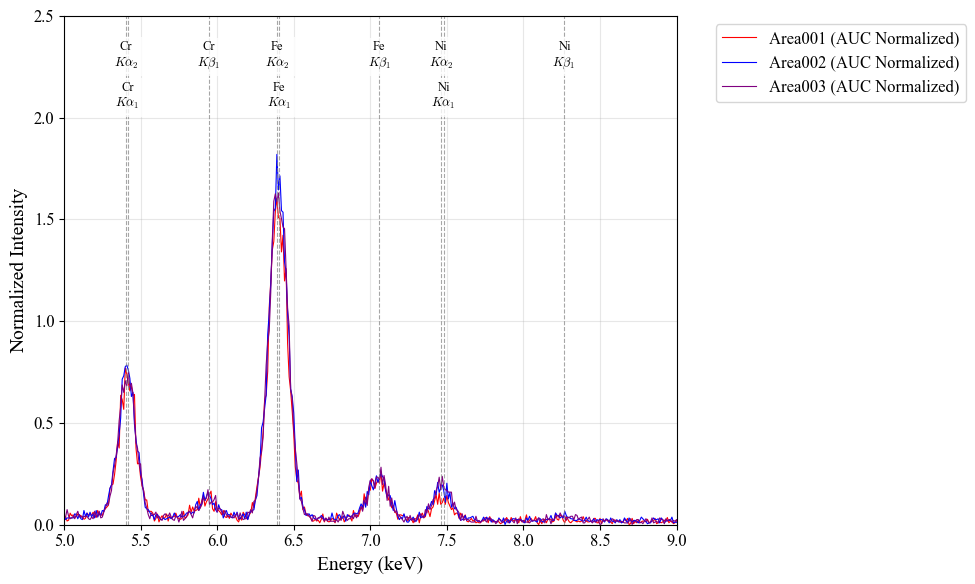

In [26]:
# Initialize
analyzer = EDSAnalyzer(
    emsa_folder=r"C:\Users\jeanv\OneDrive - Delft University of Technology\Uitwisseling - TUDelft\Courses\MEP\Experiments\SEM Pictures\SS316-3VA\3VA_porous3_areas",
    peak_db_path=r"C:\Users\jeanv\OneDrive - Delft University of Technology\Uitwisseling - TUDelft\Courses\MEP\Experiments\SEM Pictures\EDS_data.xlsx"
)

# Load data
analyzer.load_all_emsa()

# Plot with AUC Normalization
analyzer.plot_spectra(
    names=['Area001', 'Area002', 'Area003'],
    window_x=(5, 9),
    window_y=(0, 2.5),  # Adjusted for normalized spectra
    normalize=True,  # Set to True to compare relative chemical ratios
    elements=['Fe', 'Cr', 'Ni', 'O', 'Mo', 'C', 'Si', 'Mn'],
    colors=['red', 'blue', 'purple']
)